In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


In [21]:
data = pd.read_csv('saber11_pregunta_2.csv')
data

,cole_depto_ubicacion,cole_mcpio_ubicacion,cole_area_ubicacion,cole_naturaleza,estu_depto_presentacion,estu_depto_reside,punt_matematicas,punt_lectura_critica,punt_ingles,punt_c_naturales,punt_sociales_ciudadanas,punt_global
0,SANTANDER,VELEZ,URBANO,NO OFICIAL,SANTANDER,SANTANDER,33.0,23.0,45.0,36.0,38.0,167.0
1,SANTANDER,CAPITANEJO,URBANO,OFICIAL,SANTANDER,SANTANDER,83.0,59.0,52.0,69.0,60.0,333.0
2,SANTANDER,BUCARAMANGA,URBANO,OFICIAL,SANTANDER,SANTANDER,65.0,59.0,60.0,63.0,65.0,314.0
3,SANTANDER,BUCARAMANGA,URBANO,OFICIAL,SANTANDER,SANTANDER,65.0,59.0,60.0,63.0,65.0,314.0
4,SANTANDER,BUCARAMANGA,URBANO,OFICIAL,SANTANDER,SANTANDER,50.0,63.0,55.0,61.0,63.0,295.0
...,...,...,...,...,...,...,...,...,...,...,...,...
206662,SANTANDER,SUCRE,URBANO,OFICIAL,SANTANDER,SANTANDER,58.0,57.0,55.0,54.0,50.0,274.0
206663,SANTANDER,FLORIDABLANCA,URBANO,OFICIAL,SANTANDER,SANTANDER,54.0,44.0,49.0,50.0,44.0,240.0
206664,SANTANDER,FLORIDABLANCA,URBANO,OFICIAL,SANTANDER,SANTANDER,54.0,44.0,49.0,50.0,44.0,240.0
206665,SANTANDER,BUCARAMANGA,URBANO,OFICIAL,SANTANDER,SANTANDER,67.0,66.0,74.0,68.0,66.0,337.0


In [22]:
(data.isna().sum())/len(data) *100

cole_depto_ubicacion        0.0
cole_mcpio_ubicacion        0.0
cole_area_ubicacion         0.0
cole_naturaleza             0.0
estu_depto_presentacion     0.0
estu_depto_reside           0.0
punt_matematicas            0.0
punt_lectura_critica        0.0
punt_ingles                 0.0
punt_c_naturales            0.0
punt_sociales_ciudadanas    0.0
punt_global                 0.0
dtype: float64

In [23]:
data.groupby("cole_mcpio_ubicacion")["punt_global"].describe()

,count,mean,std,min,25%,50%,75%,max
cole_mcpio_ubicacion,,,,,,,,
AGUADA,155.0,262.606452,41.827335,165.0,236.0,254.0,294.50,364.0
ALBANIA,341.0,241.255132,39.314299,158.0,216.0,239.0,267.00,365.0
ARATOCA,1105.0,237.356561,43.555058,125.0,207.0,234.0,264.00,376.0
BARBOSA,3605.0,252.988904,47.860831,64.0,219.0,252.0,284.00,417.0
BARICHARA,800.0,266.805000,45.737751,150.0,233.0,265.5,297.00,428.0
...,...,...,...,...,...,...,...,...
VALLE DE SAN JOSE,554.0,252.817690,40.623944,150.0,223.0,254.5,282.75,388.0
VELEZ,2427.0,253.073342,46.535810,112.0,219.0,253.0,286.00,395.0
VETAS,195.0,234.933333,44.337281,152.0,199.0,230.0,268.00,331.0


In [24]:
grupos = [
    grupo["punt_global"].values
    for _, grupo in data.groupby("cole_mcpio_ubicacion")
]
stats.kruskal(*grupos)

KruskalResult(statistic=np.float64(17301.193000099178), pvalue=np.float64(0.0))

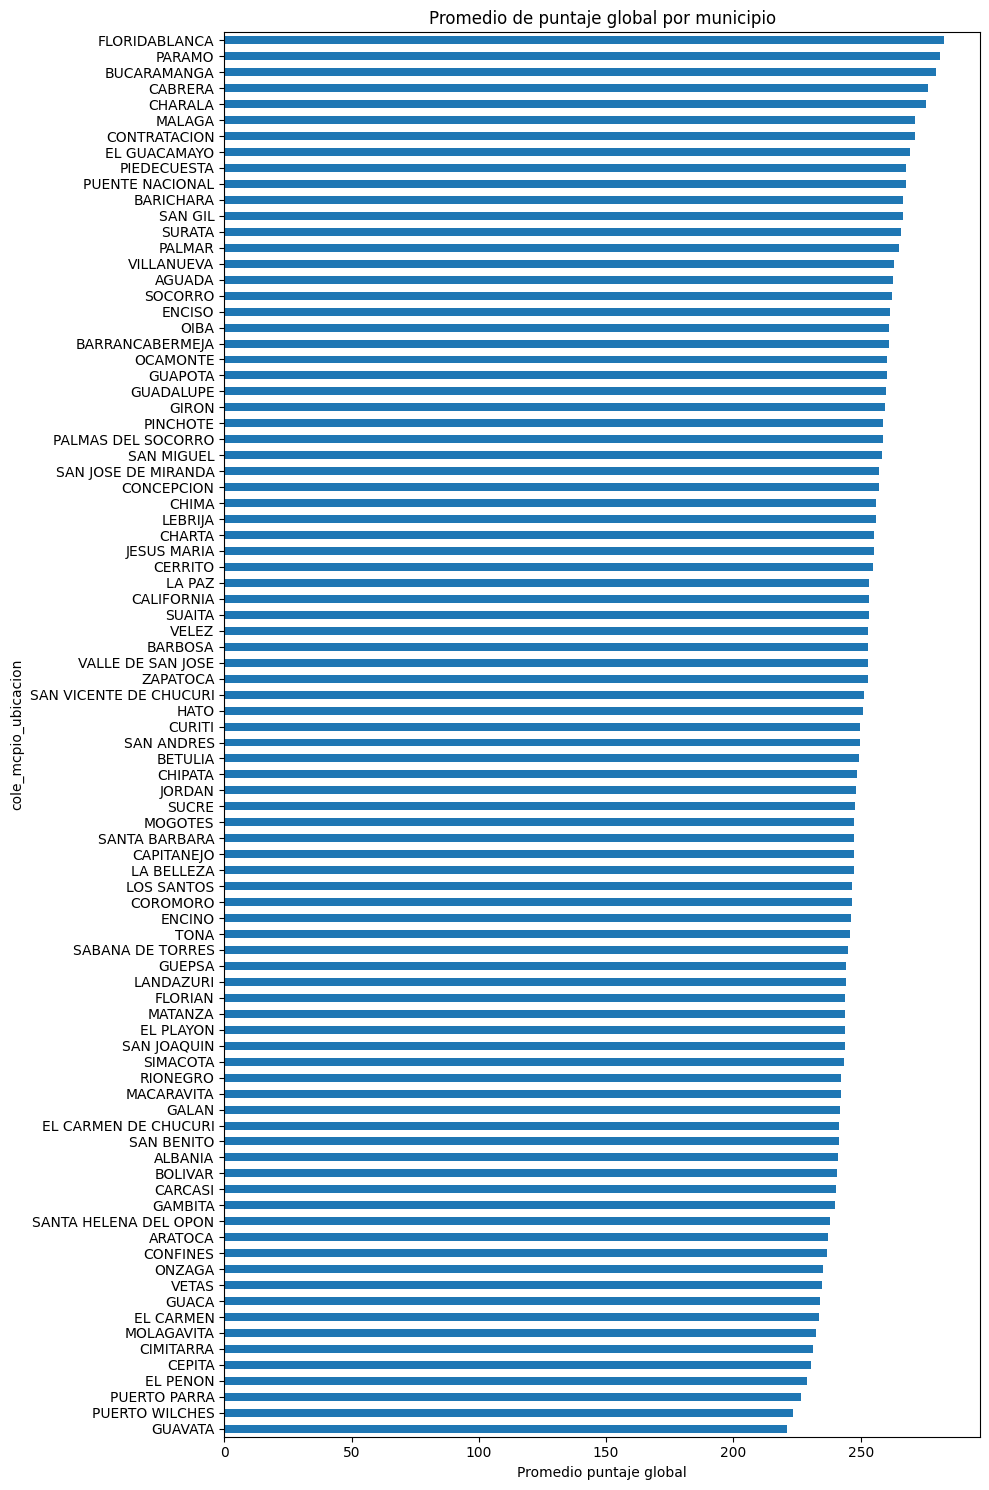

In [8]:
promedios = data.groupby("cole_mcpio_ubicacion")["punt_global"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,15))
promedios.sort_values().plot(kind='barh')
plt.title('Promedio de puntaje global por municipio')
plt.xlabel('Promedio puntaje global')
plt.tight_layout()
plt.show()

In [10]:
conteo = data["cole_mcpio_ubicacion"].value_counts()
conteo

cole_mcpio_ubicacion
BUCARAMANGA        54287
FLORIDABLANCA      24534
BARRANCABERMEJA    20073
PIEDECUESTA        15579
GIRON              13369
                   ...  
EL GUACAMAYO         166
PALMAR               163
ENCINO               161
AGUADA               155
JORDAN               135
Name: count, Length: 88, dtype: int64

In [34]:
tabla_ru = data.groupby(["cole_mcpio_ubicacion", "cole_area_ubicacion"]).size().unstack(fill_value=0)

tabla_ru.head()

cole_area_ubicacion,RURAL,URBANO
cole_mcpio_ubicacion,,
AGUADA,0,155
ALBANIA,209,132
ARATOCA,887,218
BARBOSA,1434,2171
BARICHARA,194,606


In [56]:
municipios_mixtos = tabla_ru[(tabla_ru["URBANO"] > 0) & (tabla_ru["RURAL"] > 0)].index
len(municipios_mixtos)

77

In [51]:
tabla_ru.loc[municipios_mixtos].sort_values(by="RURAL")

cole_area_ubicacion,RURAL,URBANO
cole_mcpio_ubicacion,,
CABRERA,8,159
SAN BENITO,10,159
PARAMO,15,322
CHIMA,29,197
CONFINES,34,184
...,...,...
BARBOSA,1434,2171
PUERTO WILCHES,1497,1192
SAN VICENTE DE CHUCURI,1535,1735


In [52]:
municipios_filtrados = tabla_ru[
    (tabla_ru["RURAL"] >= 30) & 
    (tabla_ru["URBANO"] >= 30)
].index

In [53]:
promedios_ru = data.groupby(["cole_mcpio_ubicacion", "cole_area_ubicacion"])["punt_global"].mean().unstack()

diferencia_ru = promedios_ru["URBANO"] - promedios_ru["RURAL"]

diferencia_ru_mixtos = diferencia_ru.loc[municipios_filtrados]

diferencia_ru_mixtos = diferencia_ru_mixtos.dropna()

diferencia_ru_mixtos.sort_values(ascending=False).head()

cole_mcpio_ubicacion
SAN JOSE DE MIRANDA    86.582348
SAN MIGUEL             71.630389
CALIFORNIA             70.121742
ENCINO                 69.047566
MACARAVITA             65.872850
dtype: float64

In [55]:
len(diferencia_ru_mixtos)

73

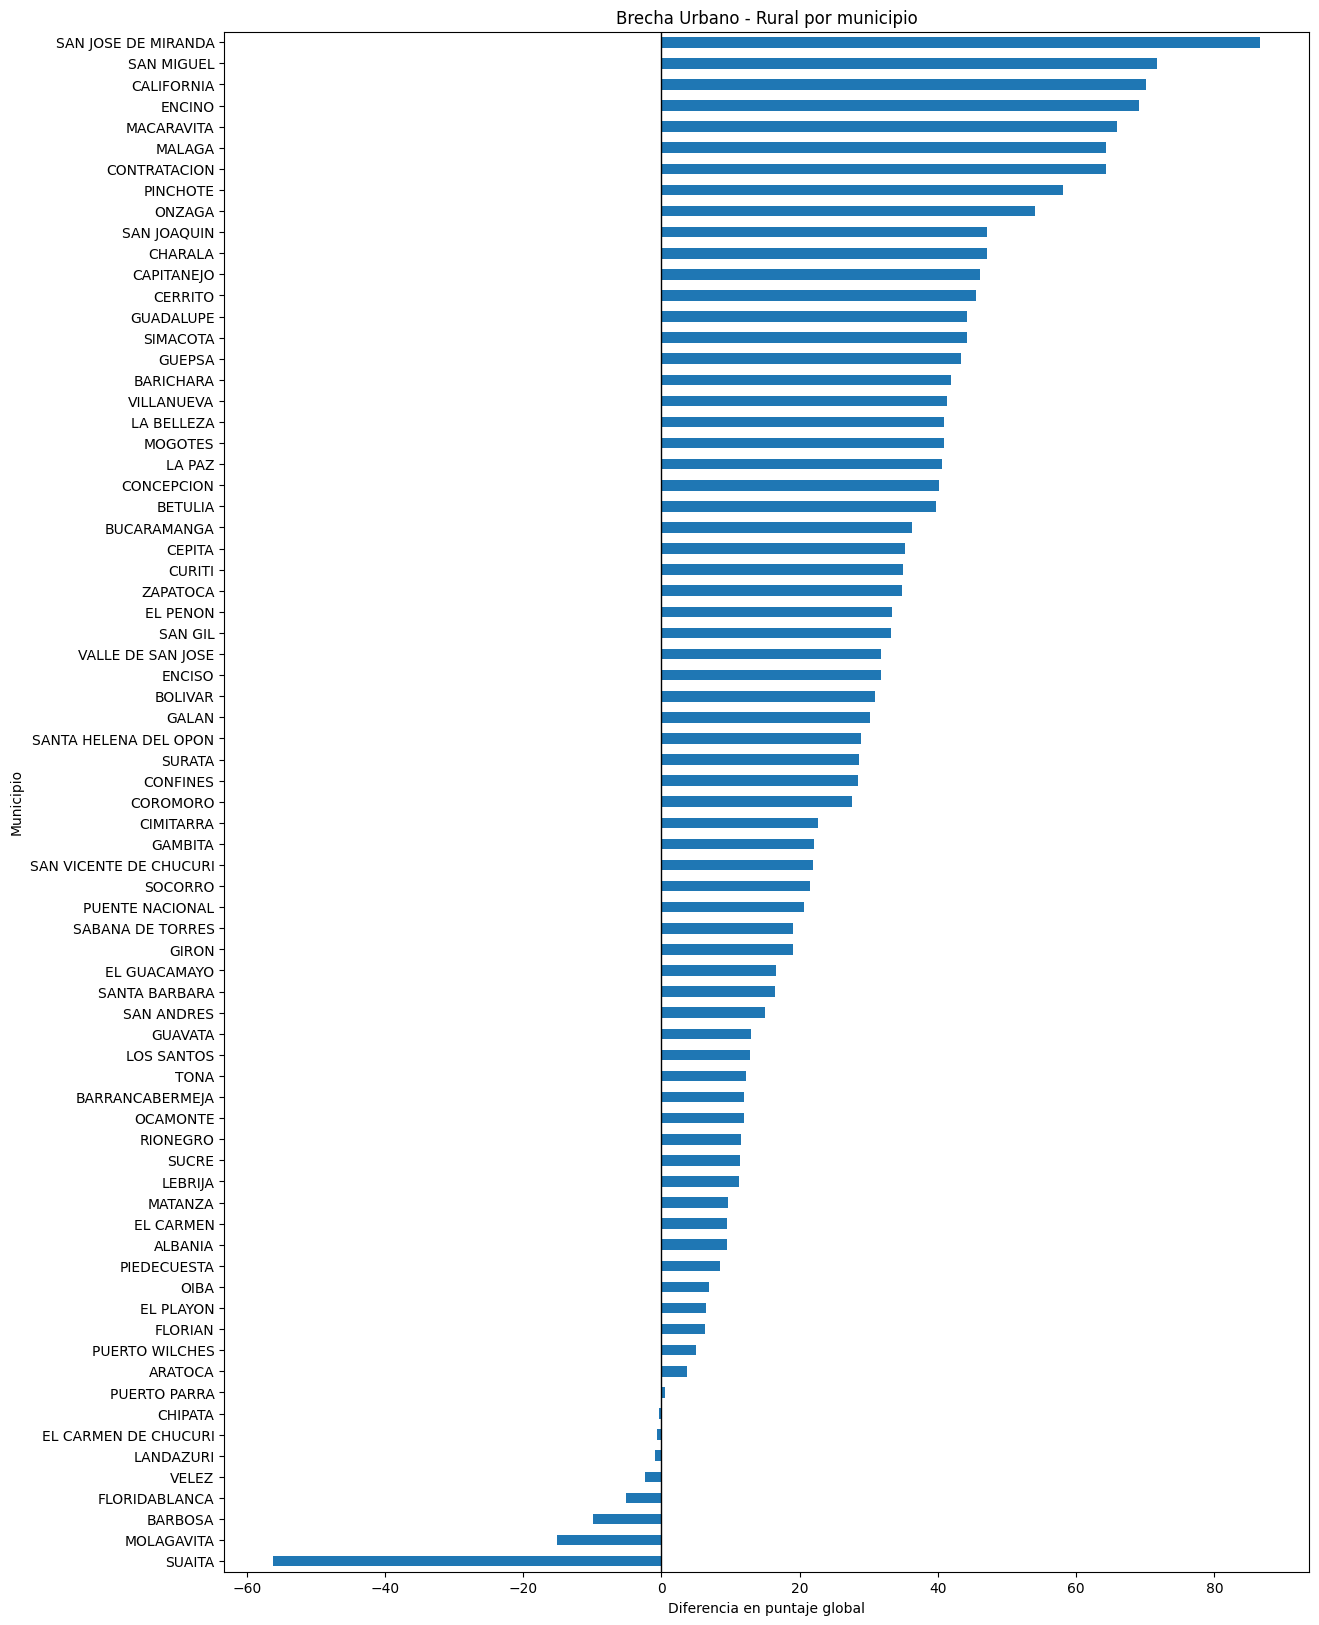

In [54]:
plt.figure(figsize=(14,20))
diferencia_ru_mixtos.sort_values().plot(kind="barh")
plt.title("Brecha Urbano - Rural por municipio")
plt.xlabel("Diferencia en puntaje global")
plt.ylabel("Municipio")
plt.axvline(0, color="black", linewidth=1)
plt.show()

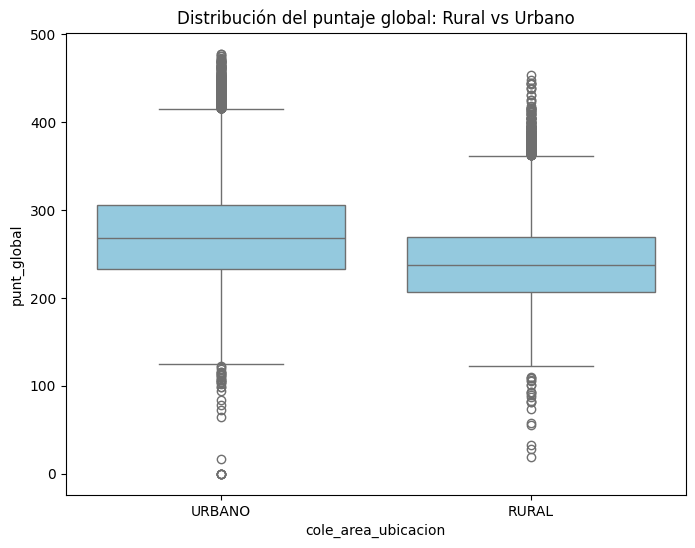

In [65]:
plt.figure(figsize=(8,6))
sns.boxplot(data=data, x="cole_area_ubicacion", y="punt_global",color="skyblue")
plt.title("Distribución del puntaje global: Rural vs Urbano")
plt.show()

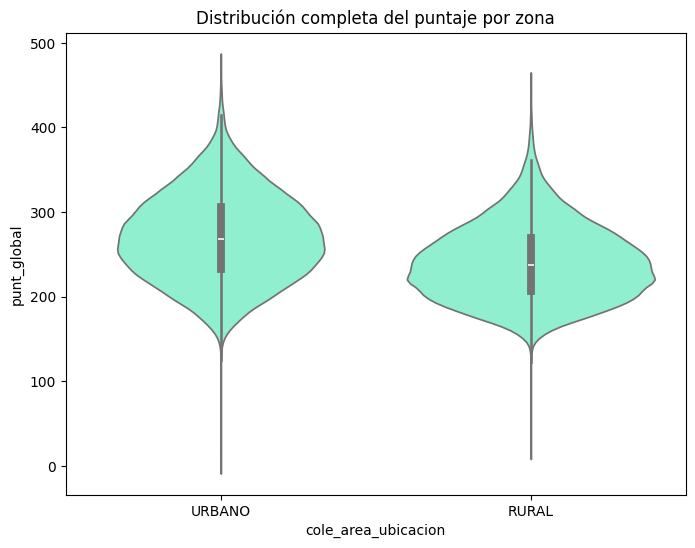

In [68]:
plt.figure(figsize=(8,6))
sns.violinplot(data=data, x="cole_area_ubicacion", y="punt_global",color="aquamarine")
plt.title("Distribución completa del puntaje por zona")
plt.show()

In [25]:
data['cole_naturaleza'].value_counts()

cole_naturaleza
OFICIAL       154690
NO OFICIAL     51977
Name: count, dtype: int64

In [57]:
tabla_nat = data.groupby(["cole_mcpio_ubicacion", "cole_naturaleza"]).size().unstack(fill_value=0)

municipios_mixtos_nat = tabla_nat[(tabla_nat["OFICIAL"] >= 30) & (tabla_nat["NO OFICIAL"] >= 30)].index
len(municipios_mixtos_nat)

68

In [58]:
promedios_nat = data.groupby(["cole_mcpio_ubicacion", "cole_naturaleza"])["punt_global"].mean().unstack()

diferencia_nat = promedios_nat["NO OFICIAL"] - promedios_nat["OFICIAL"]

diferencia_nat_mixtos = diferencia_nat.loc[municipios_mixtos_nat]

diferencia_nat_mixtos.sort_values(ascending=False).head()


cole_mcpio_ubicacion
FLORIDABLANCA       35.416066
BARRANCABERMEJA     30.662153
CIMITARRA           18.690815
BUCARAMANGA         14.881761
SABANA DE TORRES    13.688406
dtype: float64

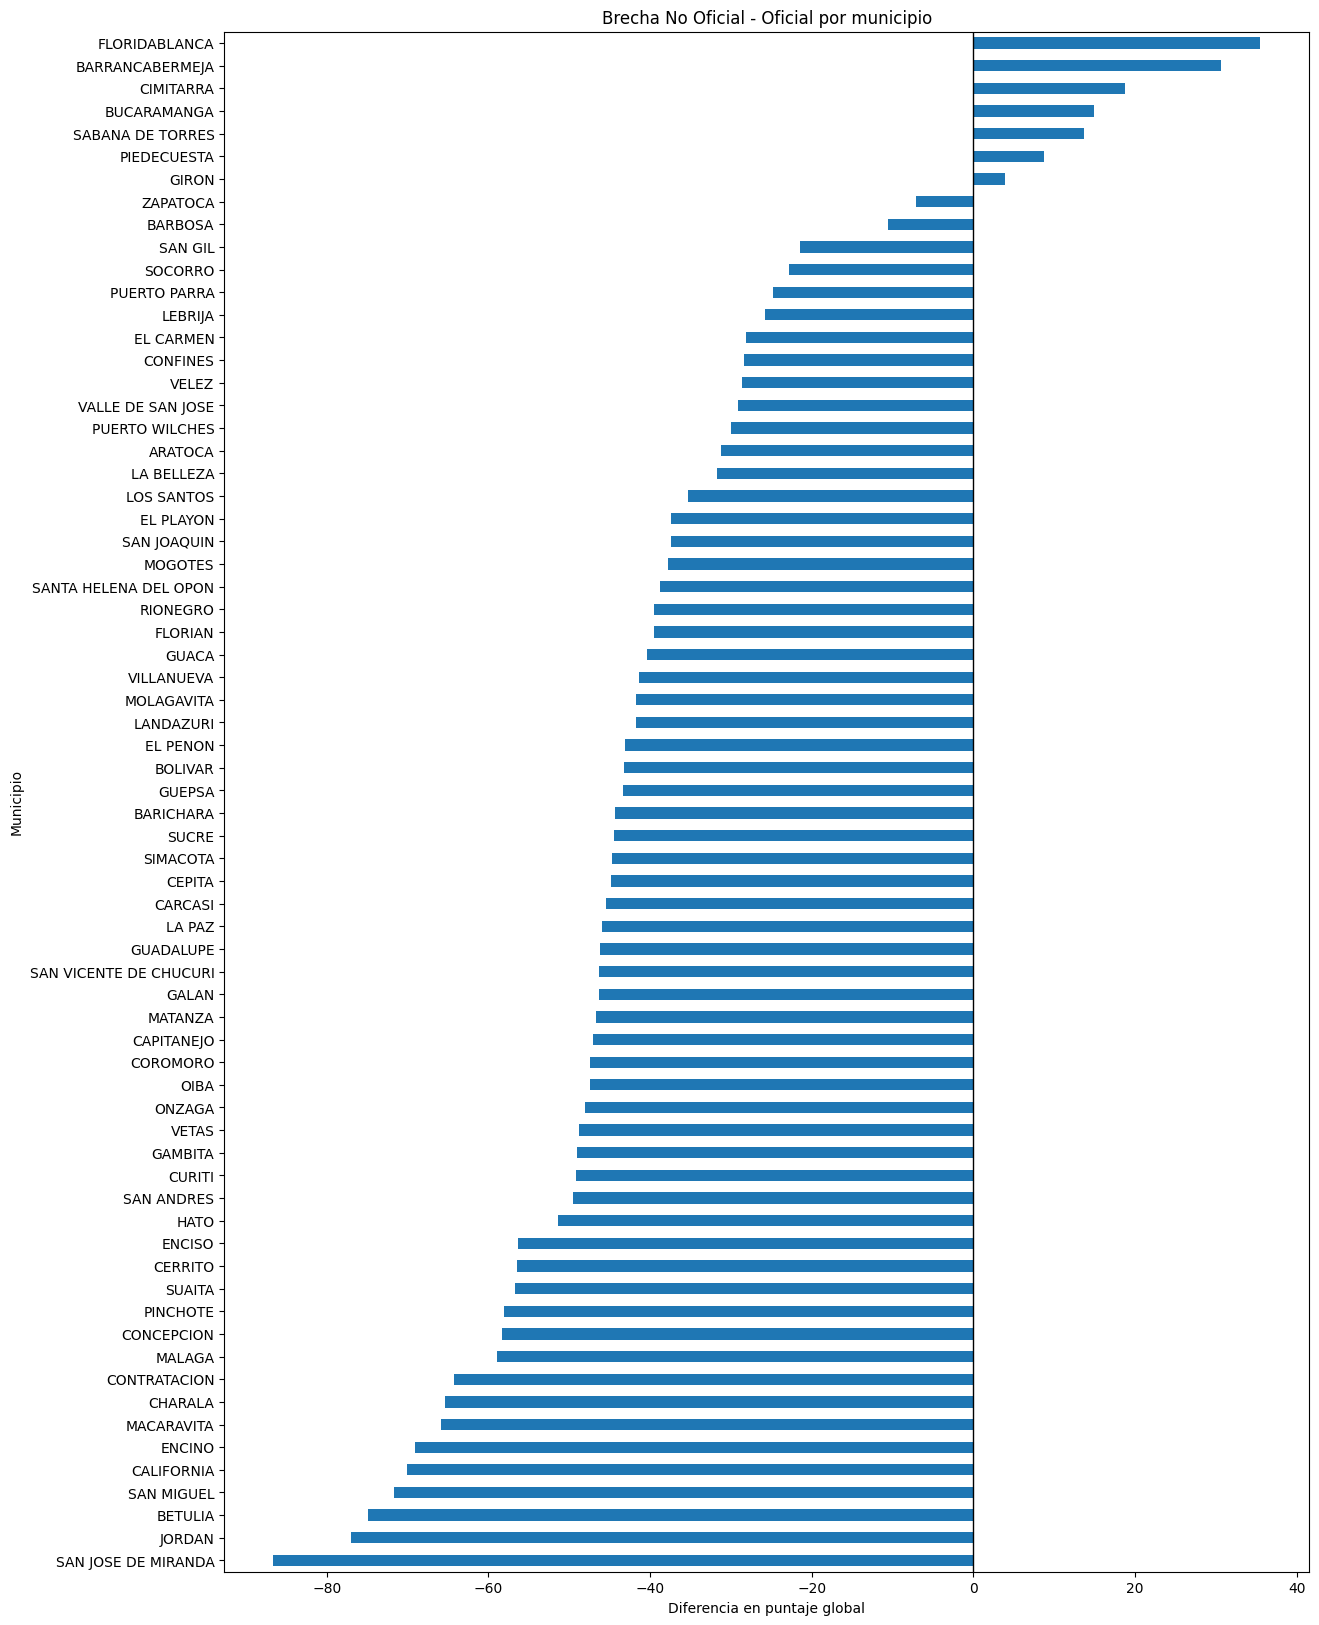

In [59]:
plt.figure(figsize=(14,20))
diferencia_nat_mixtos.sort_values().plot(kind="barh")
plt.title("Brecha No Oficial - Oficial por municipio")
plt.xlabel("Diferencia en puntaje global")
plt.ylabel("Municipio")
plt.axvline(0, color="black", linewidth=1)
plt.show()

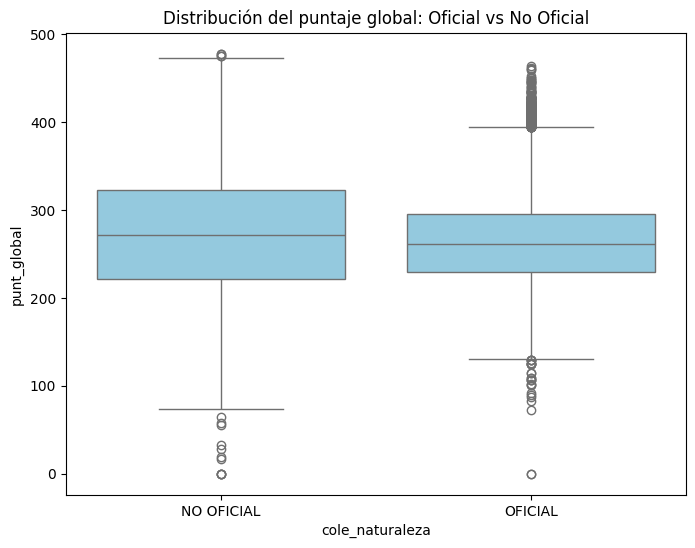

In [69]:
plt.figure(figsize=(8,6))
sns.boxplot(data=data, x="cole_naturaleza", y="punt_global",color="skyblue")
plt.title("Distribución del puntaje global: Oficial vs No Oficial")
plt.show()

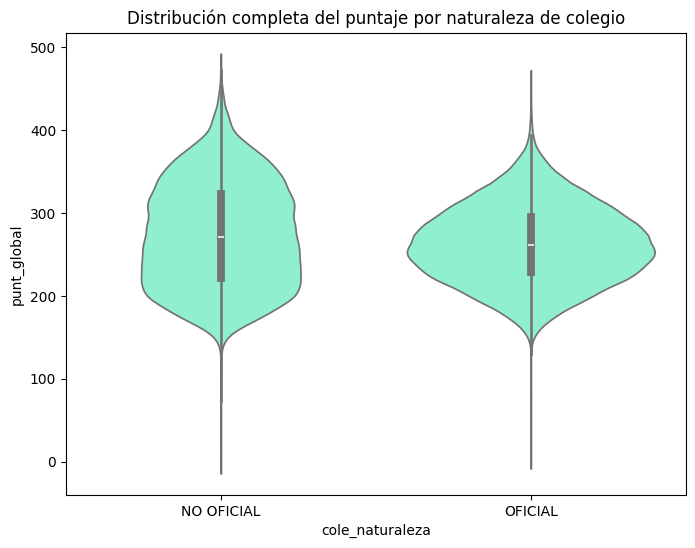

In [70]:
plt.figure(figsize=(8,6))
sns.violinplot(data=data, x="cole_naturaleza", y="punt_global",color="aquamarine")
plt.title("Distribución completa del puntaje por naturaleza de colegio")
plt.show()

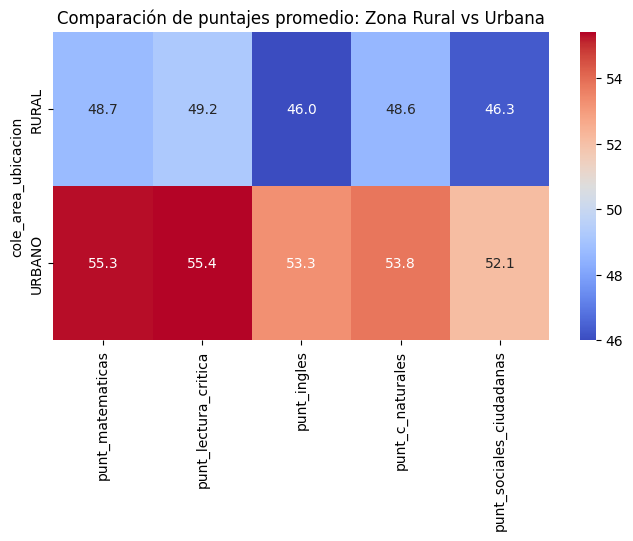

In [15]:
tabla_zona = data.groupby("cole_area_ubicacion")[[
    "punt_matematicas",
    "punt_lectura_critica",
    "punt_ingles",
    "punt_c_naturales",
    "punt_sociales_ciudadanas",
]].mean()

plt.figure(figsize=(8,4))
sns.heatmap(tabla_zona, 
            annot=True, 
            fmt=".1f", 
            cmap="coolwarm")

plt.title("Comparación de puntajes promedio: Zona Rural vs Urbana")
plt.show()